### Handling Large-Scale Datasets in Sklearn

#### 1. Problem Kya Hai? (The Memory Limit)
Ab tak hum jitna bhi data use kar rahe thay, wo chota tha aur system ki RAM (Memory) mein ek saath load ho jata tha. Par industry mein data GBs ya TBs mein hota hai. Agar saara data ek saath RAM mein load karoge, toh system **Out of Memory (OOM) Error** dekar crash ho jayega.

#### 2. Solution: Incremental Learning (Out-of-Core Learning)
Jab data bada ho, toh hum poora data ek saath model ko nahi dete. Hum data ko **chote-chote tukdon (Batches/Chunks)** mein todte hain. 
* Ek batch load karo $\rightarrow$ Model ko sikhao $\rightarrow$ RAM se delete karo.
* Agla batch laao $\rightarrow$ Wahin se aage sikhao.

#### 3. The Core Logic: `fit()` vs. `partial_fit()`
Bade data ko handle karne ke liye Sklearn hume ek special tool deta hai:
* **`fit()` (Purana Tarika):** Isey poora data ek baar mein chahiye. Agar tum isey alag-alag batch doge, toh ye pichla sab bhool jayega aur zero se start karega.
* **`partial_fit()` (Naya Hero):** Ye Incremental learning ke liye bana hai. Tum isko data ka ek chunk do, ye seekhega. Agla chunk doge, toh ye purani knowledge ko yaad rakh kar aage ki padhai (weights update) karega.

#### 4. Combining Preprocessing & Learning
Aisa nahi hai ki sirf model ko batches mein sikhana hai. Pre-processing (jaise Scaling) mein bhi poore data ka Min/Max nikalna padta hai. 
Isliye, preprocessing steps (jaise scaling) aur training (model), dono mein hume `partial_fit()` use karna padta hai taaki memory limit cross na ho.

---

### Incremental Learning: The `partial_fit` Method

#### 1. Core Logic (Batch Training)
Jab dataset RAM se bada ho, toh hum usey "Batches" (chunks) mein padhte hain. `partial_fit()` model ko ek-ek batch dekar sikhata hai. Is process ko Machine Learning mein **Out-of-Core** ya **Online Learning** bhi kehte hain.

#### 2. The Performance Catch (Overhead Problem)
Lecture ka sabse important point aakhiri line mein hai. `partial_fit()` function ko jab bhi call kiya jata hai, toh system thoda processing time waste karta hai (jise **Overhead** kehte hain). Agar tum data ko 10-10 rows ke chote batches mein todoge, toh function hazaron baar call hoga aur training bohot slow ho jayegi.

#### 3. Best Practice (Optimum Batch Size)
Is overhead se bachne ka best rule ye hai: **Batch size ko utna bada rakho jitna tumhari RAM safely sambhal sake.** (Jaise 50,000 ya 1,00,000 rows ka ek batch). Isse model ek baar mein zyada data dekhega, `partial_fit` kam baar call hoga, aur training speed fast rahegi.

---

### `partial_fit` Parameters & Supported Models

#### 1. The Syntax & Parameters
`partial_fit(X, y, classes, sample_weight)`

* **`X` aur `y`:** Tumhare current data batch ke features aur labels.
* **`classes` (V. Important):** Target variable mein total kitni categories ho sakti hain, unki list (e.g., `[0, 1, 2]`).
    * *Catch:* Isey **1st call** mein dena compulsory hai. Kyu? Ho sakta hai pehle batch mein Class '2' ka ek bhi example na ho. Agar tum `classes` nahi doge, toh naye batch mein achanak Class '2' dekh kar model crash ho jayega.
* **`sample_weight`:** (Optional) Agar kisi specific row ko zyada importance (weight) deni ho.

#### 2. Kaunse Models `partial_fit` Support Karte Hain?
Saare models batches mein nahi seekh sakte. Sklearn mein specific "Incremental" models hain:
* **Classification:** `MultinomialNB`, `BernoulliNB`, `SGDClassifier`, `Perceptron`.
* **Regression:** `SGDRegressor`.
* **Clustering:** `MiniBatchKMeans`.

#### 3. Why SGD is the King of Large Data?

Normal algorithms (jaise SVM, Random Forest, ya normal Batch Gradient Descent) ko train hone ke liye **poora data ek saath RAM mein** chahiye hota hai. Agar data bada hai, toh ye fail ho jate hain.

Doosri taraf, **SGD (Stochastic Gradient Descent)** design hi isliye kiya gaya hai taaki wo data ko chote-chote chunks mein sequentially process kar sake. Ye RAM bachata hai aur live "streaming data" (jo time ke sath lagatar aata rehta hai) par train karne ke liye best hai.

---

In [26]:
from sklearn.linear_model import SGDClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay , classification_report

In [4]:
x , y = make_classification(
    n_samples=50000,
    n_features=10,
    n_classes=3,
    n_clusters_per_class=1,
)

x_train , x_test , y_train , y_test = train_test_split(x,y , test_size=0.15)

In [8]:
import numpy as np

In [12]:
train_data = np.concatenate( ( x_train , y_train[: , np.newaxis] ) , axis=1 )

In [14]:
train_data[0:5]

array([[-0.30844269, -0.58017265,  0.40427044, -0.09439312, -1.14818914,
        -1.00054541, -1.54289889,  0.75345931,  0.34632236,  0.81561303,
         0.        ],
       [ 0.22613001, -0.54060212,  0.92638533,  0.13579112,  0.73943221,
         0.74144831, -1.51120671, -1.41926646, -0.15829585, -0.2431891 ,
         2.        ],
       [-0.35763753, -0.94825434, -0.20498927, -2.70292626,  2.65481049,
        -1.46835545,  1.06536459,  0.26774036,  1.91873532,  1.52815226,
         1.        ],
       [-0.09550729, -0.1549273 ,  0.10588394, -0.45511552,  0.29905177,
        -0.36042815,  0.76221822, -0.54025614,  0.56624874,  1.154499  ,
         1.        ],
       [ 0.34152792,  0.03235248, -0.40284188,  0.2293755 ,  1.07944672,
         1.1227083 , -1.09946408,  0.87586453,  2.24582703,  0.75481952,
         2.        ]])

In [17]:
a = np.asarray(train_data)
np.savetxt("train_data.csv" , a , delimiter=',')

In [18]:
sgd_clf = SGDClassifier(max_iter=100 , tol=0.01)

### Demystifying `partial_fit` and Out-of-Core Learning

Aapne jo questions puche hain, wo ekdam on-point hain. Machine Learning me jab data bohot bada hota hai aur humare system ke RAM me ek sath fit nahi ho pata (man lijiye 50GB ka data aur 8GB RAM), tab hum **Out-of-Core Learning** ka use karte hain. Aapka code isika ek perfect example hai.

Chaliye aapke teeno doubts ko ekdam basic se advance tak clear karte hain.

---

#### 1. Test Data Ek Sath Kyu De Rahe Hain? (Train Chunks vs Test Batch)

**Basic Intuition**
Aapka andaza bilkul sahi hai! Training data ke comparison me Test data usually bohot chhota hota hai (jaise 80% train, 20% test), isliye wo asani se RAM me ek sath fit ho jata hai. 

Lekin iske pichhe ek aur bada technical reason hai: **Memory Consumption during Processing**.
* **Training ke time:** Model ko weights update karne ke liye intermediate values (gradients, errors) memory me store karni padti hain. Isme bohot memory lagti hai, isliye hum data ko tod-tod kar (chunks me) bhejte hain.
* **Testing ke time:** Model kuch naya nahi sikh raha hota, wo bas purane sikhe hue rules apply karke predict karta hai. Prediction process bohot lightweight hota hai aur isme gradient calculation ya backpropagation nahi hota. 

**Modern Context (What if Test Data is also Huge?)**
Agar aapka test data bhi itna bada hai ki RAM me na aaye (e.g., millions of rows), toh aapko test data par bhi loop lagana padega aur chunk-by-chunk predict karke metrics manually calculate karne padenge. Lekin mostly industry cases me test data RAM me fit ho jata hai.

---

#### 2. Loop Chalane Ki Zarurat Kyu Padi? 

**Basic Intuition**
Aapko lag raha tha ki hum bas `partial_fit` ko dataset de denge aur wo khud chunking kar lega, right? Par actually Scikit-Learn ke models (jaise `SGDClassifier`) ko nahi pata hota ki aapka data file me kahan rakha hai ya usko kaise read karna hai. 

Jab hum `pd.read_csv("...", chunksize=1000)` likhte hain, toh Pandas hume pura data nahi deta, wo hume ek **Iterator (generator)** deta hai. 
Model khud file se data fetch nahi kar sakta. Isliye hume ek `for` loop lagana padta hai taaki hum Pandas se 1000 rows maangein, unko `partial_fit` ko dein, fir agle 1000 rows maangein, aur ye process tab tak chale jab tak file khatam na ho jaye.

---

#### 3. Kya Model Ek Iteration Ka Sikha Hua Memorize Karta Hai?

**Basic Intuition**
Yes, 100% true! Yahi `partial_fit` ka sabse bada magic hai jisko hum **Incremental Learning** kehte hain. 
Jab aap pehli baar chunk bhejte hain (iter==1), toh model ek basic samajh banata hai (initial weights set karta hai). Jab aap dusra chunk bhejte hain, toh model pichla sab kuch bhool kar zero se start nahi karta. Wo apne **purane knowledge (weights) ke upar** naye chunk ka knowledge add karta hai aur khud ko thoda aur fine-tune (update) kar leta hai.

Yahi reason hai ki code ke end me jab aap `sgd_clf.coef_` (weights) aur `sgd_clf.intercept_` print karte hain, toh wo lagatar update hote hue dikhte hain.

**The Mathematics (Advanced)**
Pichhe mathematics me Stochastic Gradient Descent (SGD) kaam kar raha hai. Man lijiye humare model ke weights (parameters) $w$ hain.

Har naye chunk ke aane par update rule is tarah kaam karta hai:
$$w_{t+1} = w_t - \eta \nabla J(w_t, X_{chunk}, y_{chunk})$$

Yahan:
* $w_t$ = Purane chunk se sikhe hue weights (current state).
* $X_{chunk}, y_{chunk}$ = Aapka naya 1000 rows ka data.
* $\nabla J(...)$ = Naye data par cost function $J$ ka gradient (yaani error ki disha).
* $\eta$ = Learning rate (model kitni tezi se seekhega).
* $w_{t+1}$ = Naye, updated weights jo agle iteration me use honge.

Model sirf $w_t$ ko RAM me save karke rakhta hai, aur naye data chunk ka use karke $w_{t+1}$ nikalta hai, fir purane chunk ko memory (RAM) se delete kar deta hai. Yahi wajah hai ki `partial_fit` bade se bade dataset ko bina RAM crash kiye train kar leta hai.

---

#### Key Takeaways for your Notes:
1.  **`chunksize` in Pandas:** Returns an iterator, hence the `for` loop is mandatory to manually feed chunks to the model.
2.  **`partial_fit`:** Implements online/incremental learning. It updates existing weights $\theta$ instead of recalculating from scratch.
3.  **`classes` argument:** `iter==1` me `classes=np.array([0,1,2])` dena zaroori hai kyunki pehle chunk me ho sakta hai sirf `0` aur `1` classes hi aayi hon. Model ko advance me batana padta hai ki total kitni categories exist karti hain.

In [21]:
import pandas as pd

chunksize = 1000

iter = 1

for train_df in pd.read_csv("train_data.csv" , chunksize=chunksize , iterator=True):

    if iter==1:
        x_train_partial = train_df.iloc[ : , 0:10 ]
        y_train_partial = train_df.iloc[ : , 10 ]
        sgd_clf.partial_fit(
            x_train_partial , 
            y_train_partial , 
            classes = np.array([0,1,2])
        )
    else:
        x_train_partial = train_df.iloc[ : , 0:10 ]
        y_train_partial = train_df.iloc[ : , 10 ]
        sgd_clf.partial_fit(x_train_partial , y_train_partial)

    print(f"After Iter #{iter}")
    print(sgd_clf.coef_)
    print(sgd_clf.intercept_)
    iter+=1

After Iter #1
[[-16.22740015  -7.84064576  -3.90960901  -6.08245291 -58.69126054
  -52.77211674   6.43111013  -2.17167169   6.24073811  -0.11775504]
 [ -7.67087252  -2.19936343 -14.97414042 -23.77167403   4.3734282
  -27.42945857  -2.09706231 -18.30776799   6.04006904 -12.49493276]
 [ 12.18637244  -4.21045178  17.60654016  20.60022784  19.43407166
   41.53596254  -2.51744291   4.35236656   2.48146453  12.99409074]]
[-61.24893643 -34.82376442   6.12931663]
After Iter #2
[[-13.25888421   3.64017304  -1.42168289  -9.30733202 -41.28798582
  -43.6338995   -5.82911956  -6.2672382   -3.82786057 -11.1593646 ]
 [ -4.44897315  -0.82939465  -3.6460388  -16.53408395   6.75848691
  -16.23507633  -6.90562225   4.39788157  -3.51957139   4.37851962]
 [  6.03801826  -4.53220874  -0.09619437   2.463871    21.52988697
   19.65971136  -1.49855989   8.68359324   3.82090182  -8.34445684]]
[-57.4212412  -18.40675393  -9.79329426]
After Iter #3
[[-1.27716761e+01  2.43499273e+00 -1.40802381e+00 -6.79123361e+00

In [23]:
test_score = sgd_clf.score(x_test,y_test)
print(test_score)

0.8712


c:\Users\sumit\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


c:\Users\sumit\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


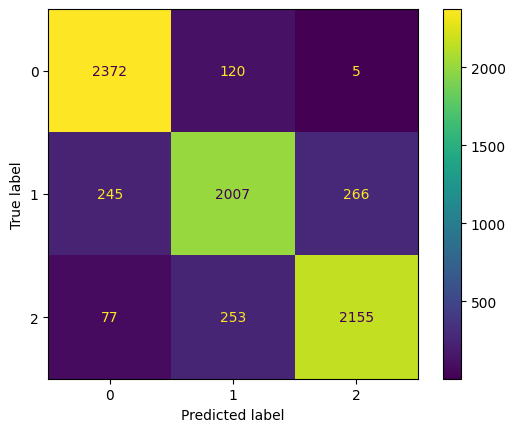

In [29]:
y_pred = sgd_clf.predict(x_test)
cm_matrix = ConfusionMatrixDisplay.from_predictions(y_test , y_pred , values_format=".5g")

In [33]:
cr = classification_report(y_test , y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.88      0.95      0.91      2497
           1       0.84      0.80      0.82      2518
           2       0.89      0.87      0.88      2485

    accuracy                           0.87      7500
   macro avg       0.87      0.87      0.87      7500
weighted avg       0.87      0.87      0.87      7500



### Incremental Preprocessing: CountVectorizer vs HashingVectorizer

#### 1. Basic Intuition: Vectorization Kya Hai?
Machine learning models (jaise Logistic Regression ya SGDClassifier) English ya Hindi ke words nahi samajh sakte; unhe sirf numbers samajh aate hain. Isliye, text data (documents, reviews, emails) ko numbers ke arrays (vectors) me convert karne ke process ko **Vectorization** kehte hain. 

Aapke notes me do sabse popular vectorizers ka comparison hai: `CountVectorizer` aur `HashingVectorizer`.

---

#### 2. CountVectorizer (The Traditional Way)
Yeh sabse basic tarika hai text ko numbers me convert karne ka.

* **Kaise kaam karta hai?** Yeh poore dataset ko padhta hai aur har unique word ki ek dictionary (vocabulary) banata hai. 
* **Example:** Agar data me 1 lakh alag-alag words hain, toh yeh 1 lakh columns ki ek dictionary RAM me save karega.
* **Problem (Drawback):** Agar aapka data bohot bada hai (e.g., Millions of rows), toh dictionary itni badi ho jayegi ki aapke computer ki RAM (Main Memory) full ho jayegi aur system crash ho sakta hai. Isliye hum isko bade data par `chunksize` ke sath use nahi kar sakte.

---

#### 3. HashingVectorizer (The Modern/Big Data Way)
Jab data itna bada ho ki RAM me fit na aaye (Out-of-Core Learning), tab hum `HashingVectorizer` ka use karte hain. 

* **Kaise kaam karta hai?** Yeh koi vocabulary ya dictionary RAM me store nahi karta! Iski jagah, yeh ek mathematical trick use karta hai jise **"The Hashing Trick"** (ya Feature Hashing) kehte hain.
* **Fix Dimensionality:** Aap pehle hi decide kar lete hain ki aapko kitne columns chahiye (e.g., `n_features = 100`). Ab har word ko directly in 100 columns me se kisi ek position par map (bhej) diya jata hai.
* **Fayda:** Kyunki yeh kuch yaad nahi rakhta (no vocabulary stored), iska object bohot lightweight hota hai aur memory save hoti hai.

---

#### 4. The Mathematics (Advanced: The Hashing Trick)
Pichhe math me yeh kaise ho raha hai bina dictionary ke? 

HashingVectorizer ek Hash Function (usually MurmurHash3) ka use karta hai. Har word (string) ko ek number me convert kiya jata hai aur fir modulo operation use karke column fix kiya jata hai.

Iska formula kuch is tarah kaam karta hai:
$$Column\_Index = Hash(word) \pmod{N}$$

Jahan:
* $word$ = Aapka input token (jaise "machine").
* $Hash()$ = Mathematical function jo text ko integer me badalta hai.
* $N$ = Total number of predefined columns (e.g., 100).

**Collision ka Concept:**
Kyunki hamare paas words millions me ho sakte hain par columns sirf 100 hain, toh math ke hisaab se multiple alag-alag words same column me ja sakte hain (jaise "apple" aur "car" dono ka index 45 aa jaye). Ise **Collision** kehte hain. Surprising baat ye hai ki machine learning models me thodi bohot collisions se accuracy par zyada farq nahi padta, aur model tab bhi achhe se pattern seekh leta hai.

---

#### 5. Connection with Incremental Learning (partial_fit)
Aapne pichle lecture me jo `partial_fit` aur `chunksize` ka loop chalaya tha, usme HashingVectorizer ka use karna zaroori hota hai.

* **Kyun?** Agar aap chunks me data model ko bhej rahe hain, toh har naye chunk me kuch naye words aa sakte hain. Agar dimensionality (columns ki ginti) badhti rahi, toh model ka matrix size bigad jayega.
* **Solution:** HashingVectorizer yeh guarantee deta hai ki chahe chunk 1 ho ya chunk 100, aur chahe usme koi bhi naya word aaye, output matrix hamesha same dimensions (columns) ka hi banega. Is wajah se purane chunk par train hua model bina kisi error ke naye chunk par `partial_fit` ho jata hai.

In [37]:
text_document = sentences = [
    "Machine learning helps computers learn patterns from large amounts of data and make predictions with better accuracy",
    
    "CountVectorizer converts textual data into numerical features so machine learning algorithms can process language efficiently",
    
    "Natural language processing enables computers to understand, analyze, and generate human language in useful ways",
    
    "Data preprocessing techniques such as tokenization, stopword removal, and normalization improve the performance of machine learning models"
]

In [45]:
max( list( len(line.split(" ")) for line in text_document ) )

17

In [35]:
from sklearn.feature_extraction.text import CountVectorizer
c_vectorizer = CountVectorizer()

In [ ]:
X_c = c_vectorizer.fit_transform(text_document)

In [39]:
X_c.shape

(4, 52)

In [49]:
c_vectorizer.vocabulary_

{'machine': 26,
 'learning': 25,
 'helps': 17,
 'computers': 8,
 'learn': 24,
 'patterns': 33,
 'from': 15,
 'large': 23,
 'amounts': 2,
 'of': 32,
 'data': 11,
 'and': 4,
 'make': 27,
 'predictions': 35,
 'with': 51,
 'better': 6,
 'accuracy': 0,
 'countvectorizer': 10,
 'converts': 9,
 'textual': 44,
 'into': 21,
 'numerical': 31,
 'features': 14,
 'so': 40,
 'algorithms': 1,
 'can': 7,
 'process': 37,
 'language': 22,
 'efficiently': 12,
 'natural': 29,
 'processing': 38,
 'enables': 13,
 'to': 46,
 'understand': 48,
 'analyze': 3,
 'generate': 16,
 'human': 18,
 'in': 20,
 'useful': 49,
 'ways': 50,
 'preprocessing': 36,
 'techniques': 43,
 'such': 42,
 'as': 5,
 'tokenization': 47,
 'stopword': 41,
 'removal': 39,
 'normalization': 30,
 'improve': 19,
 'the': 45,
 'performance': 34,
 'models': 28}

In [50]:
print(X_c)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 63 stored elements and shape (4, 52)>
  Coords	Values
  (0, 26)	1
  (0, 25)	1
  (0, 17)	1
  (0, 8)	1
  (0, 24)	1
  (0, 33)	1
  (0, 15)	1
  (0, 23)	1
  (0, 2)	1
  (0, 32)	1
  (0, 11)	1
  (0, 4)	1
  (0, 27)	1
  (0, 35)	1
  (0, 51)	1
  (0, 6)	1
  (0, 0)	1
  (1, 26)	1
  (1, 25)	1
  (1, 11)	1
  (1, 10)	1
  (1, 9)	1
  (1, 44)	1
  (1, 21)	1
  (1, 31)	1
  :	:
  (2, 46)	1
  (2, 48)	1
  (2, 3)	1
  (2, 16)	1
  (2, 18)	1
  (2, 20)	1
  (2, 49)	1
  (2, 50)	1
  (3, 26)	1
  (3, 25)	1
  (3, 32)	1
  (3, 11)	1
  (3, 4)	1
  (3, 36)	1
  (3, 43)	1
  (3, 42)	1
  (3, 5)	1
  (3, 47)	1
  (3, 41)	1
  (3, 39)	1
  (3, 30)	1
  (3, 19)	1
  (3, 45)	1
  (3, 34)	1
  (3, 28)	1


In [51]:
from sklearn.feature_extraction.text import HashingVectorizer

In [52]:
h_vectorizer = HashingVectorizer(n_features=50)

In [53]:
X_h = h_vectorizer.fit_transform(text_document)

In [54]:
X_h.shape

(4, 50)